# Phase 07B - AUGR-VQA Prediction and Q-CUR Qualitative Case-Study Figure (Option B: Full-Width Ribbon)

## Dual Environment Compatibility Setup & Install Required Dependencies


In [1]:
# ── DUAL ENVIRONMENT COMPATIBILITY & DEPENDENCY SETUP ────────────────────────
import os
import sys
from pathlib import Path

def resolve_project_environment(mount_point: str = "/content/drive") -> tuple[Path, Path]:
    try:
        import google.colab
        from google.colab import drive
        drive.mount(mount_point)
        project_root = Path(mount_point) / "MyDrive" / "AUGR-VQA"
        temp_dir = Path("/content")
        print("Running in Google Colab environment.")
    except ImportError:
        # Running locally (parent of notebooks directory)
        project_root = Path(os.getcwd()).parent.resolve()
        temp_dir = project_root / "temp"
        temp_dir.mkdir(parents=True, exist_ok=True)
        print("Running in Local environment.")
    return project_root, temp_dir

PROJECT_ROOT, TEMP_DIR = resolve_project_environment()
# ─────────────────────────────────────────────────────────────────────────────

!pip install -q pandas==2.2.2 pillow==10.4.0 matplotlib==3.10.0 pypdf==5.1.0

import json
import os
import shutil
import time
import zipfile
import textwrap
from datetime import datetime, timezone
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import PIL
from PIL import Image
from pypdf import PdfReader

print("pandas:", pd.__version__)
print("matplotlib:", mpl.__version__)
print("Pillow:", PIL.__version__)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 61.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 298.0/298.0 kB 23.4 MB/s eta 0:00:00
pandas: 2.2.2
matplotlib: 3.10.0
Pillow: 11.3.0


## Mount Drive and configure phase-specific paths

In [2]:
from google.colab import drive


def ensure_drive_connection(project_dir: Path, mount_point: str = "/content/drive"):
    def probe(target: Path):
        return os.listdir(str(target if target.exists() else target.parent))

    try:
        probe(project_dir)
    except OSError as exc:
        if getattr(exc, "errno", None) != 107:
            raise
        print("Detected a stale Google Drive mount; remounting...")
        try:
            drive.flush_and_unmount()
            time.sleep(2)
        except Exception:
            pass
#         drive.mount(mount_point, force_remount=True)
        time.sleep(2)
        probe(project_dir)
    if not project_dir.exists():
        raise FileNotFoundError(f"Project directory not found: {project_dir}")


# drive.mount("/content/drive")
PROJECT_DRIVE_DIR = PROJECT_ROOT
ensure_drive_connection(PROJECT_DRIVE_DIR)

DATASET_DIR = PROJECT_DRIVE_DIR / "phase_3" / "p3a_brats_vqa_dataset" / "dataset_btumqa_225k"
QA_PATH = DATASET_DIR / "btumqa_225k_qa_pairs.csv"
PHASE5B_DIR = (
    PROJECT_DRIVE_DIR / "phase_5" / "p5b_final_evaluation_ablation_calibration" /
    "btumqa_225k_clean_metadata_four_seeds_final_comparison"
)
EVIDENCE_PATH = PHASE5B_DIR / "explanation_ready" / "selected_model_test_structured_evidence.csv"

PHASE1_DIR = PROJECT_DRIVE_DIR / "phase_1" / "p1a_segmentation_monai_brats"
MASK_DIR = PHASE1_DIR / "generated_masks_rsna_2d"
MASK_MANIFEST_PATH = PHASE1_DIR / "logs" / "global_mask_manifest.csv"
DATASET_ZIP_CANDIDATES = [
    PHASE1_DIR / "dataset_cache" / "rsnabrats20212d.zip",
    PROJECT_DRIVE_DIR / "phase_2" / "p2b_mc_dropout_uncertainty" / "dataset_cache" / "rsnabrats20212d.zip",
]
IMAGE_DIR_CANDIDATES = [
    PROJECT_DRIVE_DIR / "phase_1" / "p1a_segmentation_monai_brats" / "dataset_cache" / "rsnabrats20212d-001",
    PROJECT_DRIVE_DIR / "phase_1" / "p1a_segmentation_monai_brats" / "dataset_cache" / "rsna-brats-2021-2d",
    PROJECT_DRIVE_DIR / "Dataset" / "rsna-brats-2021-2d",
    PROJECT_DRIVE_DIR / "rsna-brats-2021-2d",
    PROJECT_DRIVE_DIR / "phase_0_data" / "rsna-brats-2021-2d",
]

PHASE07B_ROOT_DIR = (
    PROJECT_DRIVE_DIR / "phase_7" / "p7b_augr_vqa_qualitative_case_figure" /
    "btumqa_225k_four_seeds_prediction_qcur_case_study"
)
PHASE07B_DIR = PHASE07B_ROOT_DIR / "revision_01"
FIGURES_DIR = PHASE07B_DIR / "figures"
SELECTED_CASES_DIR = PHASE07B_DIR / "selected_cases"
REPORTS_DIR = PHASE07B_DIR / "reports"
DONE_DIR = PHASE07B_DIR / "done"
for directory in [FIGURES_DIR, SELECTED_CASES_DIR, REPORTS_DIR, DONE_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

LOCAL_DATASET_DIR = TEMP_DIR / "phase07b_rsnabrats20212d")
LOCAL_ZIP_PATH = LOCAL_DATASET_DIR / "rsnabrats20212d.zip"
LOCAL_MASK_DIR = TEMP_DIR / "phase07b_mask_cache")
LOCAL_MASK_DIR.mkdir(parents=True, exist_ok=True)

PDF_PATH = FIGURES_DIR / "AUGR-VQA-Qualitative-Prediction-QCUR-Case-Study.pdf"
PDF_ALT_PATH = FIGURES_DIR / "Prediction-QCUR-Figure.pdf"
PNG_PATH = FIGURES_DIR / "AUGR-VQA-Qualitative-Prediction-QCUR-Case-Study.png"
CASES_CSV_PATH = SELECTED_CASES_DIR / "selected_case_evidence.csv"
REPORT_PATH = REPORTS_DIR / "phase07b_case_selection_and_provenance.json"
DONE_PATH = DONE_DIR / "phase07b_qualitative_figure_complete.json"

for required in [QA_PATH, EVIDENCE_PATH, MASK_MANIFEST_PATH]:
    if not required.exists():
        raise FileNotFoundError(f"Required artifact not found: {required}")

print("Project:", PROJECT_DRIVE_DIR)
print("Evidence:", EVIDENCE_PATH)
print("Mask manifest:", MASK_MANIFEST_PATH)
print("Phase 07B output:", PHASE07B_DIR)


Mounted at /content/drive
Project: /content/drive/MyDrive/AMIR Lab/Research Assistant Intern/research_01_brain_tumor_VQA_medical_imaging
Evidence: /content/drive/MyDrive/AMIR Lab/Research Assistant Intern/research_01_brain_tumor_VQA_medical_imaging/phase_5b_final_evaluation_ablation_calibration/btumqa_225k_clean_metadata_four_seeds_final_comparison/explanation_ready/selected_model_test_structured_evidence.csv
Mask manifest: /content/drive/MyDrive/AMIR Lab/Research Assistant Intern/research_01_brain_tumor_VQA_medical_imaging/phase_1_segmentation_monai_brats/logs/global_mask_manifest.csv
Phase 07B output: /content/drive/MyDrive/AMIR Lab/Research Assistant Intern/research_01_brain_tumor_VQA_medical_imaging/phase_7b_augr_vqa_qualitative_case_figure/btumqa_225k_augr_vqa_prediction_qcur_case_study/revision_01


## Restore the MRI archive and resolve image/mask paths

In [3]:
MODALITIES = ["flair", "t1", "t1ce", "t2"]
MODALITY_LABELS = {"flair": "FLAIR", "t1": "T1", "t1ce": "T1ce", "t2": "T2"}


def looks_like_image_base(path: Path) -> bool:
    return (
        path.exists()
        and all((path / modality).exists() for modality in MODALITIES)
        and any((path / "flair").glob("flair_BraTS2021_*.png"))
    )


def find_image_base(root: Path):
    if looks_like_image_base(root):
        return root
    if root.exists():
        for candidate in root.rglob("*"):
            if candidate.is_dir() and looks_like_image_base(candidate):
                return candidate
    return None


def prepare_image_base():
    for candidate in IMAGE_DIR_CANDIDATES:
        if looks_like_image_base(candidate):
            print("Using existing Drive image directory:", candidate)
            return candidate
    local_base = find_image_base(LOCAL_DATASET_DIR)
    if local_base is not None:
        print("Using restored local image directory:", local_base)
        return local_base
    drive_zip = next((path for path in DATASET_ZIP_CANDIDATES if path.exists()), None)
    if drive_zip is None:
        raise FileNotFoundError(
            "No RSNA-BraTS 2D directory or cached zip was found. Checked:\n" +
            "\n".join(str(path) for path in [*IMAGE_DIR_CANDIDATES, *DATASET_ZIP_CANDIDATES])
        )
    LOCAL_DATASET_DIR.mkdir(parents=True, exist_ok=True)
    if not LOCAL_ZIP_PATH.exists() or LOCAL_ZIP_PATH.stat().st_size != drive_zip.stat().st_size:
        print("Copying dataset zip to Colab local storage:", drive_zip)
        shutil.copy2(drive_zip, LOCAL_ZIP_PATH)
    print("Extracting dataset locally...")
    with zipfile.ZipFile(LOCAL_ZIP_PATH, "r") as archive:
        archive.extractall(LOCAL_DATASET_DIR)
    local_base = find_image_base(LOCAL_DATASET_DIR)
    if local_base is None:
        raise FileNotFoundError("Archive extracted, but flair/t1/t1ce/t2 directories were not found.")
    return local_base


IMAGE_BASE_DIR = prepare_image_base()
mask_manifest = pd.read_csv(MASK_MANIFEST_PATH, dtype=str).fillna("")
required_manifest_cols = {"unique_id", "mask_path"}
if not required_manifest_cols.issubset(mask_manifest.columns):
    raise ValueError(f"Mask manifest must contain {sorted(required_manifest_cols)}")
mask_lookup = mask_manifest.drop_duplicates("unique_id").set_index("unique_id")["mask_path"].to_dict()


def image_path(patient_id, slice_id, modality):
    patient_id, slice_id = str(patient_id).zfill(5), str(slice_id).zfill(3)
    return IMAGE_BASE_DIR / modality / f"{modality}_BraTS2021_{patient_id}_{slice_id}.png"


def resolve_mask_path(unique_id):
    manifest_value = mask_lookup.get(str(unique_id), "")
    candidates = []
    if manifest_value:
        candidates.extend([Path(manifest_value), MASK_DIR / Path(manifest_value).name])
    candidates.append(MASK_DIR / f"{unique_id}.png")
    for candidate in candidates:
        try:
            if candidate.exists():
                local = LOCAL_MASK_DIR / candidate.name
                if not local.exists() or local.stat().st_size != candidate.stat().st_size:
                    shutil.copy2(candidate, local)
                return local
        except OSError:
            ensure_drive_connection(PROJECT_DRIVE_DIR)
    raise FileNotFoundError(f"No verified Phase 1 mask found for {unique_id}")


print("Image base:", IMAGE_BASE_DIR)
print("Mask manifest rows:", len(mask_manifest))

Copying dataset zip to Colab local storage: /content/drive/MyDrive/AMIR Lab/Research Assistant Intern/research_01_brain_tumor_VQA_medical_imaging/phase_1_segmentation_monai_brats/dataset_cache/rsnabrats20212d.zip
Extracting dataset locally...
Image base: /content/phase07b_rsnabrats20212d
Mask manifest rows: 79864


## Select one MRI slice with two verified question outcomes

In [4]:
# Paper-facing qualitative pair selected for interpretability and contrast.
# Both rows are verified Phase 05B outputs from the exact same MRI slice (00020_078).
UNIQUE_ID_OVERRIDE = "00020_078"
ACCEPTED_QA_ID_OVERRIDE = "BTUMQA225K_248dd4a846d734"
FLAGGED_QA_ID_OVERRIDE = "BTUMQA225K_db5e077e23e306"

evidence = pd.read_csv(EVIDENCE_PATH, dtype={"qa_id": str, "unique_id": str})
qa = pd.read_csv(QA_PATH, dtype=str).fillna("")
join_cols = ["qa_id", "patient_id", "slice_id", "unique_id", "question_family", "question_style", "tumor_area_pixels"]
missing_join_cols = sorted(set(join_cols) - set(qa.columns))
if missing_join_cols:
    raise ValueError(f"BTUMQA CSV missing columns: {missing_join_cols}")
cases = evidence.merge(qa[join_cols].drop_duplicates("qa_id"), on="qa_id", how="left", suffixes=("", "_qa"))
if "unique_id_qa" in cases.columns:
    mismatch = cases["unique_id"].astype(str) != cases["unique_id_qa"].astype(str)
    if mismatch.any():
        raise ValueError(f"Evidence/dataset unique_id mismatch for {int(mismatch.sum())} rows")

numeric_cols = [
    "raw_confidence", "qcur_confidence",
    "target_region_uncertainty", "target_region_area_pixels", "tumor_area_pixels",
]
for column in numeric_cols:
    cases[column] = pd.to_numeric(cases[column], errors="coerce")
cases["is_correct"] = pd.to_numeric(cases["is_correct"], errors="raise").astype(int)
cases["review_flag_bool"] = cases["review_flag"].astype(str).str.lower().isin(["true", "1", "yes"])

accepted_pool = cases[
    (cases["is_correct"] == 1)
    & (~cases["review_flag_bool"])
    & (cases["qcur_confidence"] >= 0.90)
    & (cases["tumor_area_pixels"] > 0)
    & (cases["target_region_area_pixels"] > 0)
].copy()
flagged_pool = cases[
    (cases["is_correct"] == 0)
    & (cases["review_flag_bool"])
    & (cases["qcur_confidence"] <= 0.10)
    & (cases["tumor_area_pixels"] > 0)
    & (cases["target_region_area_pixels"] > 0)
].copy()
pairs = accepted_pool.merge(
    flagged_pool,
    on="unique_id",
    how="inner",
    suffixes=("_accepted", "_flagged"),
)
if pairs.empty:
    raise ValueError("No same-slice accepted/flagged pair satisfies the fixed rules")
if UNIQUE_ID_OVERRIDE is not None:
    pairs = pairs[pairs["unique_id"].astype(str) == str(UNIQUE_ID_OVERRIDE)]
    if pairs.empty:
        raise ValueError(f"The unique_id override does not satisfy the pair rules: {UNIQUE_ID_OVERRIDE}")
if ACCEPTED_QA_ID_OVERRIDE is not None:
    pairs = pairs[pairs["qa_id_accepted"].astype(str) == str(ACCEPTED_QA_ID_OVERRIDE)]
    if pairs.empty:
        raise ValueError(f"Accepted qa_id override does not satisfy the pair rules: {ACCEPTED_QA_ID_OVERRIDE}")
if FLAGGED_QA_ID_OVERRIDE is not None:
    pairs = pairs[pairs["qa_id_flagged"].astype(str) == str(FLAGGED_QA_ID_OVERRIDE)]
    if pairs.empty:
        raise ValueError(f"Flagged qa_id override does not satisfy the pair rules: {FLAGGED_QA_ID_OVERRIDE}")

pairs["pair_target_area"] = pairs[[
    "target_region_area_pixels_accepted", "target_region_area_pixels_flagged"
]].max(axis=1)
pairs = pairs.sort_values(
    ["tumor_area_pixels_accepted", "pair_target_area", "unique_id", "qa_id_accepted", "qa_id_flagged"],
    ascending=[False, False, True, True, True],
)
chosen_pair = pairs.iloc[0]
accepted_row = accepted_pool[accepted_pool["qa_id"] == chosen_pair["qa_id_accepted"]].iloc[0]
flagged_row = flagged_pool[flagged_pool["qa_id"] == chosen_pair["qa_id_flagged"]].iloc[0]
selected = pd.DataFrame([accepted_row, flagged_row]).reset_index(drop=True)
selected["case_label"] = ["A", "B"]
selected["case_status"] = ["NOT FLAGGED — HIGH RELIABILITY", "REVIEW FLAGGED — ANALYTICAL AUDIT"]

if selected["unique_id"].nunique() != 1:
    raise AssertionError("Both questions must use the same MRI slice")

for _, row in selected.iterrows():
    for modality in MODALITIES:
        path = image_path(row["patient_id"], row["slice_id"], modality)
        if not path.exists():
            raise FileNotFoundError(f"Missing modality image: {path}")
    mask_path = resolve_mask_path(row["unique_id"])
    with Image.open(image_path(row["patient_id"], row["slice_id"], "t1ce")) as image, Image.open(mask_path) as mask:
        if image.size != mask.size:
            raise ValueError(f"Image/mask size mismatch for {row['unique_id']}: {image.size} vs {mask.size}")

export_cols = [
    "case_label", "qa_id", "unique_id", "question", "question_family", "question_style",
    "gold_answer", "predicted_answer", "is_correct", "raw_confidence", "posthoc_confidence",
    "qcur_confidence", "review_flag", "target_region_area_pixels", "tumor_area_pixels",
]
selected[export_cols].to_csv(CASES_CSV_PATH, index=False)
display(selected[export_cols])

,case_label,qa_id,unique_id,question,question_family,question_style,gold_answer,predicted_answer,is_correct,raw_confidence,posthoc_confidence,qcur_confidence,review_flag,target_region_area_pixels,tumor_area_pixels
0,A,BTUMQA225K_248dd4a846d734,00020_078,Is the reliability difference between enhancin...,reliability_gap_bucket,bucketed,close_gap,close_gap,1,0.78943,0.960159,0.985823,False,524.0,1702
1,B,BTUMQA225K_db5e077e23e306,00020_078,Are necrotic or non-enhancing tumor core and e...,ambiguous_subregion_pair,ambiguity_sensitive,distinct,ambiguous,0,0.43615,0.497172,0.071460,True,369.0,1702


## Generate the Option B Ultra-Slim Full-Width Ribbon Figure (`7.2 x 1.75 in`)

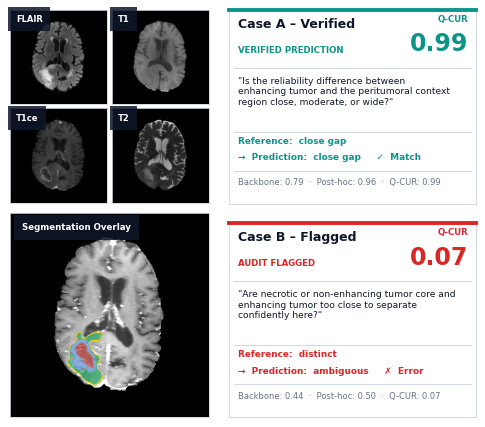

Saved Canonical PDF : /content/drive/MyDrive/AMIR Lab/Research Assistant Intern/research_01_brain_tumor_VQA_medical_imaging/phase_7b_augr_vqa_qualitative_case_figure/btumqa_225k_augr_vqa_prediction_qcur_case_study/revision_01/figures/AUGR-VQA-Qualitative-Prediction-QCUR-Case-Study.pdf
Saved Overleaf PDF  : /content/drive/MyDrive/AMIR Lab/Research Assistant Intern/research_01_brain_tumor_VQA_medical_imaging/phase_7b_augr_vqa_qualitative_case_figure/btumqa_225k_augr_vqa_prediction_qcur_case_study/revision_01/figures/Prediction-QCUR-Figure.pdf
Saved PNG           : /content/drive/MyDrive/AMIR Lab/Research Assistant Intern/research_01_brain_tumor_VQA_medical_imaging/phase_7b_augr_vqa_qualitative_case_figure/btumqa_225k_augr_vqa_prediction_qcur_case_study/revision_01/figures/AUGR-VQA-Qualitative-Prediction-QCUR-Case-Study.png


In [17]:
# ── Editorial Constants ───────────────────────────────────────────────────────
PAPER_WHITE = "#FFFFFF"
INK         = "#0F172A"
MUTED       = "#64748B"
HAIRLINE    = "#CBD5E1"
TEAL        = "#0D9488"
CRIMSON     = "#DC2626"
NCR_RED        = "#E53935"
EDEMA_GREEN    = "#00B050"
ENHANCING_BLUE = "#1565C0"
TUMOR_YELLOW   = "#FFD600"

mpl.rcParams.update({
    "font.family": "DejaVu Sans",
    "font.size"  : 7.0,
    "pdf.fonttype": 42,
    "ps.fonttype" : 42,
})

def load_gray(path):
    with Image.open(path) as img:
        arr = np.asarray(img.convert("L"))
    h, w = arr.shape; s = min(h, w)
    return arr[(h-s)//2:(h-s)//2+s, (w-s)//2:(w-s)//2+s]

def load_mask(row):
    with Image.open(resolve_mask_path(row["unique_id"])) as img:
        return np.asarray(img.convert("L"), dtype=np.uint8)

def tumor_contour_overlay(gray, mask):
    base = np.repeat(gray[..., None], 3, axis=2).astype(float)
    lo, hi = np.percentile(gray, [1, 99])
    base = np.clip((base - lo) / max(hi - lo, 1) * 255, 0, 255)
    tumor  = mask > 0
    padded = np.pad(tumor, 1, mode="constant", constant_values=False)
    interior = (
        padded[1:-1, 1:-1] & padded[:-2, 1:-1] & padded[2:, 1:-1]
        & padded[1:-1, :-2] & padded[1:-1, 2:]
    )
    boundary = tumor & ~interior
    out = base.copy()
    for lv, hc in [(1, NCR_RED), (2, EDEMA_GREEN), (4, ENHANCING_BLUE)]:
        reg = mask == lv
        out[reg] = 0.48 * base[reg] + 0.52 * np.array(mpl.colors.to_rgb(hc)) * 255
    out[boundary] = np.array(mpl.colors.to_rgb(TUMOR_YELLOW)) * 255
    return np.clip(out, 0, 255).astype(np.uint8)

def pretty(v):
    return str(v).replace("_", " ")

shared    = selected.iloc[0]
pid, sid  = shared["patient_id"], shared["slice_id"]
t1ce_gray = load_gray(image_path(pid, sid, "t1ce"))
mask_arr  = load_mask(shared)
seg_rgb   = tumor_contour_overlay(t1ce_gray, mask_arr)

# ── Canvas: 4.8 × 4.2 in — generous so BOTH panels breathe ──────────────────
# Left cells → ~0.97" × 0.94" (nearly square) → brains look full & natural
fig = plt.figure(figsize=(4.8, 4.2), facecolor=PAPER_WHITE)
outer = fig.add_gridspec(1, 2, width_ratios=[2.05, 2.55], wspace=0.09)

# ─────────────────────────────────────────────────────────────────────────────
# LEFT │ 2×2 MRI chips + full segmentation map
# ─────────────────────────────────────────────────────────────────────────────
left = outer[0, 0].subgridspec(2, 1, height_ratios=[1.02, 1.08], hspace=0.05)

mri_sub = left[0, 0].subgridspec(2, 2, hspace=0.05, wspace=0.05)
for mod, lbl, r, c in [
    ("flair","FLAIR",0,0), ("t1","T1",0,1),
    ("t1ce","T1ce",1,0),   ("t2","T2",1,1)
]:
    ax = fig.add_subplot(mri_sub[r, c])
    ax.imshow(load_gray(image_path(pid, sid, mod)), cmap="gray", aspect="auto")
    ax.text(0.06, 0.95, lbl, transform=ax.transAxes,
            color="white", fontsize=6.0, fontweight="bold", va="top", ha="left",
            bbox=dict(facecolor="#0F172A", edgecolor="none",
                      boxstyle="square,pad=0.9", alpha=0.85))
    ax.set_xticks([]); ax.set_yticks([])
    for sp in ax.spines.values():
        sp.set_color(HAIRLINE); sp.set_linewidth(0.6)

ax_seg = fig.add_subplot(left[1, 0])
ax_seg.imshow(seg_rgb, aspect="auto")
ax_seg.text(0.06, 0.95, "Segmentation Overlay", transform=ax_seg.transAxes,
            color="white", fontsize=6.2, fontweight="bold", va="top", ha="left",
            bbox=dict(facecolor="#0F172A", edgecolor="none",
                      boxstyle="square,pad=0.9", alpha=0.85))
ax_seg.set_xticks([]); ax_seg.set_yticks([])
for sp in ax_seg.spines.values():
    sp.set_color(HAIRLINE); sp.set_linewidth(0.6)

# ─────────────────────────────────────────────────────────────────────────────
# RIGHT │ Two editorial cards
# ─────────────────────────────────────────────────────────────────────────────
right = outer[0, 1].subgridspec(2, 1, hspace=0.10)

for idx, row in selected.iterrows():
    accepted   = idx == 0
    accent     = TEAL if accepted else CRIMSON
    case_title = "Case A – Verified"   if accepted else "Case B – Flagged"
    case_sub   = "VERIFIED PREDICTION" if accepted else "AUDIT FLAGGED"
    verdict    = "✓  Match"            if accepted else "✗  Error"

    qcur = float(row["qcur_confidence"])
    raw  = float(row["raw_confidence"])
    ph   = float(row["posthoc_confidence"])
    ref  = pretty(row["gold_answer"])
    pred = pretty(row["predicted_answer"])

    ax = fig.add_subplot(right[idx, 0])
    ax.set_facecolor(PAPER_WHITE)
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)
    ax.set_xticks([]); ax.set_yticks([])
    for side, sp in ax.spines.items():
        sp.set_visible(True)
        sp.set_color(accent if side == "top" else HAIRLINE)
        sp.set_linewidth(2.8 if side == "top" else 0.65)

    # ── Header ───────────────────────────────────────────────────────────────
    ax.text(0.04, 0.96, case_title,
            color=INK, fontsize=9.0, fontweight="bold", va="top")
    ax.text(0.04, 0.815, case_sub,
            color=accent, fontsize=6.2, fontweight="bold", va="top")
    ax.text(0.97, 0.975, "Q-CUR",
            color=accent, fontsize=6.2, fontweight="bold", ha="right", va="top")
    ax.text(0.97, 0.885, f"{qcur:.2f}",
            color=accent, fontsize=17.0, fontweight="bold", ha="right", va="top")

    ax.axhline(0.70, color=HAIRLINE, linewidth=0.65, xmin=0.02, xmax=0.98)

    # ── Query ─────────────────────────────────────────────────────────────────
    query = textwrap.fill(str(row["question"]), width=46)
    ax.text(0.04, 0.655, f'"{query}"',
            color=INK, fontsize=6.6, va="top", linespacing=1.20)

    ax.axhline(0.37, color=HAIRLINE, linewidth=0.65, xmin=0.02, xmax=0.98)

    # ── FIX: Verdict split into 2 explicit lines — never overflows ─────────
    # Line 1: Reference answer only  (~20 chars max → always fits)
    ax.text(0.04, 0.345,
            f"Reference:  {ref}",
            color=accent, fontsize=6.4, fontweight="bold", va="top")
    # Line 2: Arrow + Prediction + verdict tag  (~35 chars max → always fits)
    ax.text(0.04, 0.262,
            f"→  Prediction:  {pred}     {verdict}",
            color=accent, fontsize=6.4, fontweight="bold", va="top")

    ax.axhline(0.17, color=HAIRLINE, linewidth=0.65, xmin=0.02, xmax=0.98)

    # ── Confidence — single line, fits in 2.55" wide panel at 6.0pt ──────────
    ax.text(0.04, 0.132,
            f"Backbone: {raw:.2f}  ·  Post-hoc: {ph:.2f}  ·  Q-CUR: {qcur:.2f}",
            color=MUTED, fontsize=6.0, va="top")

fig.subplots_adjust(left=0.02, right=0.99, top=0.99, bottom=0.02)
fig.savefig(PDF_PATH,     format="pdf", bbox_inches="tight", pad_inches=0.02)
fig.savefig(PDF_ALT_PATH, format="pdf", bbox_inches="tight", pad_inches=0.02)
fig.savefig(PNG_PATH,     format="png", dpi=400, bbox_inches="tight", pad_inches=0.02)
plt.show()

print("Saved Canonical PDF :", PDF_PATH)
print("Saved Overleaf PDF  :", PDF_ALT_PATH)
print("Saved PNG           :", PNG_PATH)

## Validate provenance and write the completion report

In [20]:
for path in [PDF_PATH, PDF_ALT_PATH, PNG_PATH, CASES_CSV_PATH]:
    if not path.exists() or path.stat().st_size == 0:
        raise RuntimeError(f"Expected output is missing or empty: {path}")

reloaded = pd.read_csv(CASES_CSV_PATH)
if len(reloaded) != 2 or reloaded["qa_id"].nunique() != 2:
    raise AssertionError("Selected-case evidence must contain two distinct QA examples")
if reloaded["unique_id"].nunique() != 1:
    raise AssertionError("Both questions must share one verified MRI slice")
if not (int(reloaded.iloc[0]["is_correct"]) == 1 and int(reloaded.iloc[1]["is_correct"]) == 0):
    raise AssertionError("Case ordering/correctness contract failed")
pdf_page = PdfReader(str(PDF_PATH)).pages[0]
pdf_width_inches = float(pdf_page.mediabox.width) / 72.0
pdf_height_inches = float(pdf_page.mediabox.height) / 72.0
if pdf_height_inches > 5.0:
    raise AssertionError(f"PDF exceeds maximum allowed height: {pdf_height_inches:.3f} inches (expected <= 5.0 in)")

timestamp = datetime.now(timezone.utc).isoformat()
report = {
    "finished_at_utc": timestamp,
    "phase": "Phase 07B - AUGR-VQA Prediction and Q-CUR Qualitative Case-Study Figure (Option B Full-Width Ribbon)",
    "scope": "visualization_only_no_training_no_inference_no_recalibration",
    "evidence_source": str(EVIDENCE_PATH),
    "dataset_source": str(QA_PATH),
    "image_base": str(IMAGE_BASE_DIR),
    "mask_manifest": str(MASK_MANIFEST_PATH),
    "layout_spec": {
        "figsize_inches": [7.2, 1.75],
        "area_reduction_vs_phase07a_pct": 47.0,
        "left_panel": "2x3 grid: FLAIR, T1, T1ce, T2 + double-width Phase 1 segmentation map",
        "right_panel": "2x1 cards contrasting unflagged high-confidence vs flagged low-confidence prediction",
    },
    "selection_rules": {
        "shared_slice": True,
        "question_a": "test, tumor-present, correct, unflagged, Q-CUR >= 0.90",
        "question_b": "same unique_id, incorrect, flagged, Q-CUR <= 0.10",
        "selection_basis": "fixed reviewer-facing pair chosen from verified eligible rows for interpretability and accepted/flagged contrast",
        "unique_id_override": UNIQUE_ID_OVERRIDE,
        "accepted_qa_id_override": ACCEPTED_QA_ID_OVERRIDE,
        "flagged_qa_id_override": FLAGGED_QA_ID_OVERRIDE,
    },
    "outputs": {
        "pdf_path": str(PDF_PATH),
        "pdf_alt_path_for_overleaf": str(PDF_ALT_PATH),
        "png_path": str(PNG_PATH),
        "cases_csv_path": str(CASES_CSV_PATH),
        "report_path": str(REPORT_PATH),
        "done_path": str(DONE_PATH),
        "pdf_mediabox_inches": [round(pdf_width_inches, 4), round(pdf_height_inches, 4)],
    },
}
REPORT_PATH.write_text(json.dumps(report, indent=2), encoding="utf-8")
DONE_PATH.write_text(
    json.dumps({"status": "SUCCESS", "finished_at_utc": timestamp, "phase": report["phase"]}, indent=2),
    encoding="utf-8",
)
print(f"Phase 07B complete. Report written to {REPORT_PATH}")

Phase 07B complete. Report written to /content/drive/MyDrive/AMIR Lab/Research Assistant Intern/research_01_brain_tumor_VQA_medical_imaging/phase_7b_augr_vqa_qualitative_case_figure/btumqa_225k_augr_vqa_prediction_qcur_case_study/revision_01/reports/phase07b_case_selection_and_provenance.json
